# Gradient Boosting és XGBoost modellek - Predictive Maintenance

Ebben a notebookban két fa alapú boosting modellt építünk a predictive maintenance adathalmazra.

A cél a `target` változó előrejelzése, amely azt jelzi, hogy történt-e meghibásodás.

A notebookban két modellt hasonlítunk össze:

- GradientBoostingClassifier
- XGBClassifier

A modelleket először baseline beállításokkal vizsgáljuk, majd hiperparaméter-tuningot és threshold tuningot is alkalmazunk.

## 1. Modell relevanciája és elméleti háttér

A boosting olyan ensemble tanulási módszer, amely több gyengébb modellt kombinál egy erősebb modellé. A boosting modellek jellemzően több döntési fát építenek egymás után.

A módszer lényege, hogy minden újabb fa az előző modellek hibáit próbálja javítani. Így a modell fokozatosan tanulja meg azokat a mintázatokat, amelyeket a korábbi fák még nem kezeltek jól.

A predictive maintenance feladatban ez azért lehet hasznos, mert a meghibásodásokat gyakran több változó együttes hatása magyarázza. Például a nyomaték, fordulatszám, hőmérséklet és szerszámkopás kombinációja együtt jelezhet kockázatos gépállapotot.

## 2. Gradient Boosting és XGBoost rövid összehasonlítása

A `GradientBoostingClassifier` a scikit-learn klasszikus gradient boosting implementációja. Több döntési fát épít egymás után, és minden lépésben az előző modell hibáit próbálja csökkenteni.

Az `XGBoost` szintén gradient boosting alapú algoritmus, de optimalizáltabb és több szabályozási lehetőséget biztosít. Gyakran erős teljesítményt ad tabuláris adatokon.

Az XGBoost egyik fontos előnye, hogy a `scale_pos_weight` paraméter segítségével figyelembe tudja venni az osztályok kiegyensúlyozatlanságát. Ez ebben a projektben különösen fontos, mert a meghibásodási esetek ritkák.

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    cross_val_predict
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    make_scorer
)

pd.set_option("display.max_columns", None)

In [16]:
try:
    from xgboost import XGBClassifier
    print("XGBoost sikeresen importálva.")
except ImportError:
    print("Az xgboost csomag nincs telepítve. Telepítés:")
    print("pip install xgboost")

XGBoost sikeresen importálva.


## 3. Train és test adatok beolvasása

A tanító és teszt adathalmazt a korábbi adat-előkészítési lépések során létrehozott CSV fájlokból olvassuk be.

A test adathalmazt nem használjuk tanításra vagy hiperparaméter-tuningra, csak a végső modellértékeléshez.

In [17]:
TRAIN_PATH = Path("../../DataCleaning/train.csv")
TEST_PATH = Path("../../DataCleaning/test.csv")

print("Train fájl létezik:", TRAIN_PATH.exists())
print("Test fájl létezik:", TEST_PATH.exists())

print("Train path:", TRAIN_PATH.resolve())
print("Test path:", TEST_PATH.resolve())

Train fájl létezik: True
Test fájl létezik: True
Train path: /home/matetopolyai/mateown/repo/MLBeadando/Codes/DataCleaning/train.csv
Test path: /home/matetopolyai/mateown/repo/MLBeadando/Codes/DataCleaning/test.csv


In [18]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train méret:", train_df.shape)
print("Test méret:", test_df.shape)

train_df.head()

Train méret: (8000, 9)
Test méret: (2000, 9)


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,temperature_difference_k,type_L,type_M,target
0,302.0,310.9,1456,47.2,54,8.9,0,1,0
1,297.0,308.3,1399,46.4,132,11.3,0,1,0
2,301.0,311.6,1357,45.6,137,10.6,0,1,0
3,298.9,309.8,1411,56.3,84,10.9,1,0,0
4,297.1,308.5,1733,28.7,50,11.4,1,0,0


In [19]:
test_df.head()

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,temperature_difference_k,type_L,type_M,target
0,300.5,309.8,1345,62.7,153,9.3,1,0,0
1,303.7,312.4,1513,40.1,135,8.7,1,0,0
2,302.5,311.4,1559,37.6,209,8.9,1,0,0
3,295.6,306.3,1509,35.8,60,10.7,0,0,0
4,300.5,310.0,1358,60.4,102,9.5,0,0,0


## 4. Alapellenőrzések

A modellezés előtt ellenőrizzük:

- a train és test oszlopok egyezését,
- a `target` oszlop meglétét,
- a hiányzó értékeket,
- az adathalmaz alapvető szerkezetét.

In [20]:
print("Train oszlopok:")
print(train_df.columns.tolist())

print("\nTest oszlopok:")
print(test_df.columns.tolist())

print("\nEgyeznek az oszlopok?")
print(train_df.columns.tolist() == test_df.columns.tolist())

print("\nVan target oszlop a trainben?")
print("target" in train_df.columns)

print("\nVan target oszlop a testben?")
print("target" in test_df.columns)

Train oszlopok:
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'temperature_difference_k', 'type_L', 'type_M', 'target']

Test oszlopok:
['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'temperature_difference_k', 'type_L', 'type_M', 'target']

Egyeznek az oszlopok?
True

Van target oszlop a trainben?
True

Van target oszlop a testben?
True


In [21]:
missing_summary = pd.DataFrame({
    "train_missing": train_df.isna().sum(),
    "test_missing": test_df.isna().sum()
})

missing_summary

,train_missing,test_missing
air_temperature_k,0,0
process_temperature_k,0,0
rotational_speed_rpm,0,0
torque_nm,0,0
tool_wear_min,0,0
temperature_difference_k,0,0
type_L,0,0
type_M,0,0
target,0,0


## 5. A `type` változó kezelése

Az eredeti `type` változó három kategóriát tartalmazott: `L`, `M` és `H`.

Az adat-előkészítés során one-hot encodingot alkalmaztunk `drop_first=True` beállítással. Emiatt csak két dummy változó szerepel az adathalmazban:

- `type_L`
- `type_M`

A harmadik kategória, vagyis a `type_H`, referencia kategóriaként értelmezhető:

- `type_L = 0` és `type_M = 0` → `type_H`
- `type_L = 1` és `type_M = 0` → `type_L`
- `type_L = 0` és `type_M = 1` → `type_M`

In [22]:
type_columns = [col for col in train_df.columns if col.startswith("type_")]

print("Type dummy oszlopok:", type_columns)

if "type_L" in train_df.columns and "type_M" in train_df.columns:
    print("A type_L és type_M oszlopok megtalálhatók.")
else:
    print("Figyelem: valamelyik type dummy oszlop hiányzik.")

Type dummy oszlopok: ['type_L', 'type_M']
A type_L és type_M oszlopok megtalálhatók.


## 6. Magyarázó változók és célváltozó szétválasztása

A `target` oszlop a célváltozó, ezt szeretnénk előrejelezni.

A többi oszlop lesz a modell bemeneti változója.

In [23]:
X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]

X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]

print("X_train méret:", X_train.shape)
print("y_train méret:", y_train.shape)

print("X_test méret:", X_test.shape)
print("y_test méret:", y_test.shape)

X_train méret: (8000, 8)
y_train méret: (8000,)
X_test méret: (2000, 8)
y_test méret: (2000,)


## 7. Osztályeloszlás ellenőrzése

A predictive maintenance adathalmaz erősen kiegyensúlyozatlan. A meghibásodás nélküli esetek jelentik a többségi osztályt, míg a meghibásodások ritkábban fordulnak elő.

Ezért az accuracy mellett kiemelten vizsgáljuk a precision, recall, F1-score, ROC-AUC és average precision metrikákat is.

In [24]:
def target_distribution_summary(y, name):
    counts = y.value_counts().sort_index()
    ratios = y.value_counts(normalize=True).sort_index() * 100
    
    summary = pd.DataFrame({
        "dataset": name,
        "count": counts,
        "ratio_percent": ratios.round(2)
    })
    
    return summary

In [25]:
train_target_summary = target_distribution_summary(y_train, "train")
test_target_summary = target_distribution_summary(y_test, "test")

target_summary = pd.concat([train_target_summary, test_target_summary])

target_summary

,dataset,count,ratio_percent
target,,,
0,train,7729,96.61
1,train,271,3.39
0,test,1932,96.60
1,test,68,3.40


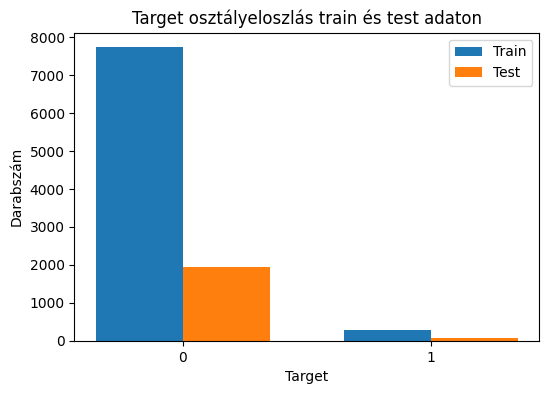

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))

train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

x = np.arange(len(train_counts.index))
width = 0.35

ax.bar(x - width / 2, train_counts.values, width, label="Train")
ax.bar(x + width / 2, test_counts.values, width, label="Test")

ax.set_title("Target osztályeloszlás train és test adaton")
ax.set_xlabel("Target")
ax.set_ylabel("Darabszám")
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index)
ax.legend()

plt.show()

## 8. Modellspecifikus előfeldolgozás

A Gradient Boosting és XGBoost fa alapú modellek. A döntési fák küszöbértékek alapján osztják fel az adatokat, ezért ezek a modellek általában nem igényelnek skálázást.

Ez eltér például a logisztikus regressziótól vagy SVM-től, ahol a skálázás fontos lehet.

Ebben a notebookban ezért nem használunk StandardScaler-t.

## 9. Osztály imbalance kezelése XGBoost esetén

Az XGBoost modellben a `scale_pos_weight` paraméter segítségével figyelembe tudjuk venni, hogy a pozitív osztály ritka.

A paramétert a negatív és pozitív osztály elemszámának arányából számítjuk:

`scale_pos_weight = negatív osztály darabszáma / pozitív osztály darabszáma`

Így a ritkább meghibásodási osztály nagyobb súlyt kap a tanítás során.

In [27]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negatív osztály darabszáma:", negative_count)
print("Pozitív osztály darabszáma:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 4))

Negatív osztály darabszáma: 7729
Pozitív osztály darabszáma: 271
scale_pos_weight: 28.5203


## 10. Baseline modellek létrehozása

Először alapbeállítású modelleket hozunk létre.

A GradientBoostingClassifier esetén a scikit-learn alapmodelljét használjuk.

Az XGBoost esetén a `scale_pos_weight` paramétert már a baseline modellben is beállítjuk, mert a célváltozó erősen kiegyensúlyozatlan.

In [28]:
gradient_boosting_pipeline = Pipeline([
    ("model", GradientBoostingClassifier(random_state=42))
])

xgboost_pipeline = Pipeline([
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1
    ))
])

models = {
    "GradientBoosting": gradient_boosting_pipeline,
    "XGBoost": xgboost_pipeline
}

## 11. Keresztvalidáció beállítása

A baseline modelleket először 5-szörös Stratified K-Fold keresztvalidációval értékeljük a train adaton.

A stratifikáció azért fontos, mert a pozitív osztály ritka, és szeretnénk, hogy minden foldban hasonló maradjon az osztályarány.

In [29]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

## 12. Baseline modellek keresztvalidációs értékelése

A keresztvalidáció során a modelleket csak a train adaton értékeljük. A test adatot továbbra sem használjuk, azt csak a végső értékeléshez tartjuk fenn.

In [30]:
cv_results = []
cv_details = {}

for model_name, model in models.items():
    print(f"Keresztvalidáció futtatása: {model_name}")
    
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    
    cv_details[model_name] = scores
    
    result_row = {
        "model": model_name
    }
    
    for metric in scoring.keys():
        result_row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        result_row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    
    cv_results.append(result_row)

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

Keresztvalidáció futtatása: GradientBoosting
Keresztvalidáció futtatása: XGBoost


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,GradientBoosting,0.9865,0.0012,0.8919,0.0208,0.6865,0.0554,0.7739,0.0278,0.9738,0.0135,0.8379,0.0234
1,XGBoost,0.9839,0.0028,0.7615,0.0483,0.7677,0.0422,0.7637,0.0380,0.9666,0.0101,0.8143,0.0408


## 13. Baseline modellek végső tesztelése

A keresztvalidáció után a baseline modelleket betanítjuk a teljes train adaton, majd kiértékeljük a test adaton.

A test adathalmazt csak ezen a ponton használjuk a modell valós teljesítményének mérésére.

In [31]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "average_precision": average_precision_score(y_test, y_proba)
    }
    
    return results, y_pred, y_proba

In [32]:
baseline_test_results = {}
baseline_predictions = {}
baseline_probabilities = {}
fitted_baseline_models = {}

for model_name, model in models.items():
    print(f"Modell tanítása és tesztelése: {model_name}")
    
    model.fit(X_train, y_train)
    
    results, y_pred, y_proba = evaluate_model(
        model,
        X_test,
        y_test,
        model_name
    )
    
    baseline_test_results[model_name] = results
    baseline_predictions[model_name] = y_pred
    baseline_probabilities[model_name] = y_proba
    fitted_baseline_models[model_name] = model

baseline_test_results_df = pd.DataFrame(baseline_test_results).T.reset_index(drop=True)

baseline_test_results_df.round(4)

Modell tanítása és tesztelése: GradientBoosting
Modell tanítása és tesztelése: XGBoost


,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,GradientBoosting,0.9895,0.912281,0.764706,0.832,0.976111,0.866532
1,XGBoost,0.9855,0.782609,0.794118,0.788321,0.981062,0.86101


In [33]:
for model_name in models.keys():
    print("=" * 80)
    print(f"Classification report - {model_name}")
    print("=" * 80)
    print(classification_report(
        y_test,
        baseline_predictions[model_name],
        zero_division=0
    ))

Classification report - GradientBoosting
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.91      0.76      0.83        68

    accuracy                           0.99      2000
   macro avg       0.95      0.88      0.91      2000
weighted avg       0.99      0.99      0.99      2000

Classification report - XGBoost
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.78      0.79      0.79        68

    accuracy                           0.99      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.99      0.99      0.99      2000



## 14. Confusion matrix

A confusion matrix megmutatja, hogy a modell hány esetet sorolt helyesen és helytelenül az egyes osztályokba.

Predictive maintenance környezetben különösen fontos a false negative esetek száma, mert ezek olyan meghibásodások, amelyeket a modell nem jelzett előre.

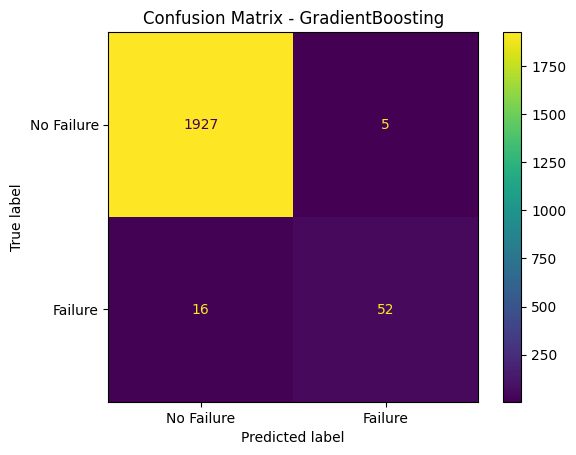

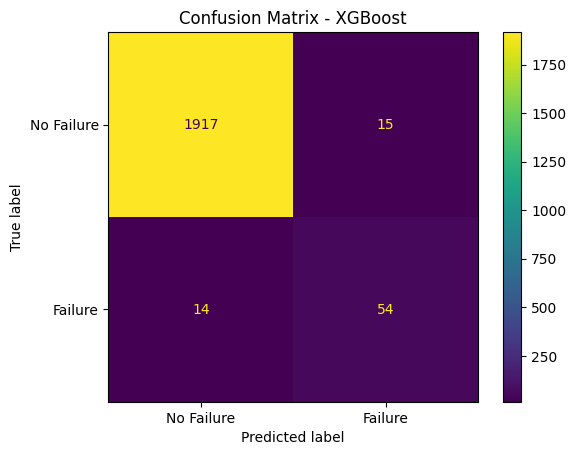

In [34]:
for model_name in models.keys():
    cm = confusion_matrix(y_test, baseline_predictions[model_name])
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Failure", "Failure"]
    )
    
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

## 15. ROC görbe és AUC

A ROC görbe a true positive rate és false positive rate kapcsolatát mutatja különböző döntési küszöbök mellett.

A ROC-AUC érték azt méri, hogy a modell mennyire jól képes elkülöníteni a két osztályt.

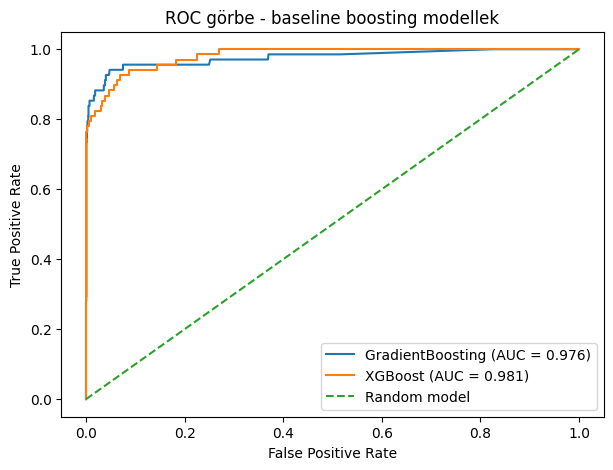

In [35]:
plt.figure(figsize=(7, 5))

for model_name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, baseline_probabilities[model_name])
    auc_value = roc_auc_score(y_test, baseline_probabilities[model_name])
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random model")

plt.title("ROC görbe - baseline boosting modellek")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 16. Precision-Recall görbe

Kiegyensúlyozatlan osztályeloszlás esetén a Precision-Recall görbe különösen hasznos, mert jobban fókuszál a ritka pozitív osztály felismerésére.

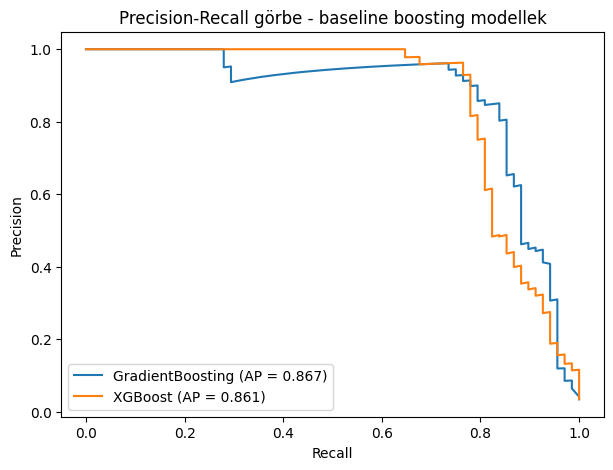

In [36]:
plt.figure(figsize=(7, 5))

for model_name in models.keys():
    precision, recall, _ = precision_recall_curve(
        y_test,
        baseline_probabilities[model_name]
    )
    
    ap_value = average_precision_score(
        y_test,
        baseline_probabilities[model_name]
    )
    
    plt.plot(recall, precision, label=f"{model_name} (AP = {ap_value:.3f})")

plt.title("Precision-Recall görbe - baseline boosting modellek")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()



## 17. Feature importance vizsgálata

A fa alapú modellek egyik előnye, hogy becslést adnak arra, mely változók járultak hozzá leginkább a döntésekhez.

A feature importance segítségével megvizsgálhatjuk, hogy a modellek mely szenzorváltozókat tartották legfontosabbnak a meghibásodás előrejelzésében.

In [37]:
def get_feature_importance(fitted_pipeline, feature_names, model_name):
    model = fitted_pipeline.named_steps["model"]
    
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_,
        "model": model_name
    }).sort_values("importance", ascending=False)
    
    return importance_df

In [38]:
feature_importance_dfs = []

for model_name, fitted_model in fitted_baseline_models.items():
    importance_df = get_feature_importance(
        fitted_model,
        X_train.columns,
        model_name
    )
    
    feature_importance_dfs.append(importance_df)

feature_importance_df = pd.concat(feature_importance_dfs, ignore_index=True)

feature_importance_df

,feature,importance,model
0,torque_nm,0.379430,GradientBoosting
1,rotational_speed_rpm,0.260483,GradientBoosting
2,tool_wear_min,0.184045,GradientBoosting
3,temperature_difference_k,0.136541,GradientBoosting
4,type_L,0.021848,GradientBoosting
5,process_temperature_k,0.008223,GradientBoosting
6,air_temperature_k,0.006174,GradientBoosting
7,type_M,0.003256,GradientBoosting
8,rotational_speed_rpm,0.316952,XGBoost
9,torque_nm,0.244005,XGBoost


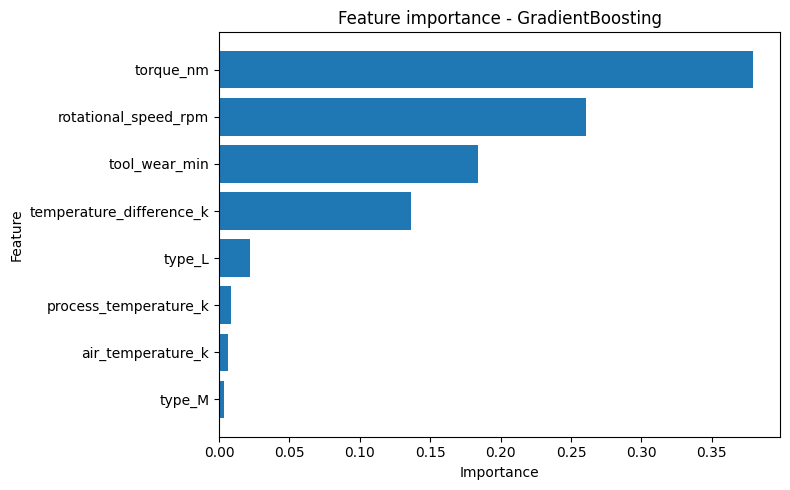

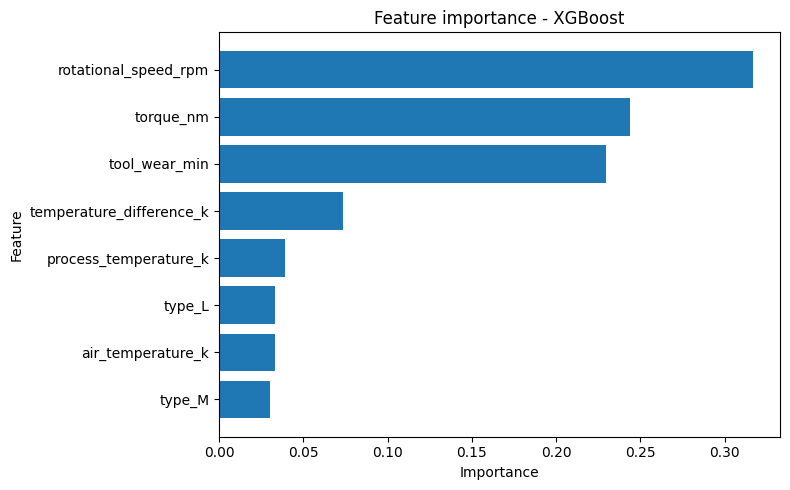

In [39]:
for model_name in feature_importance_df["model"].unique():
    plot_df = feature_importance_df[
        feature_importance_df["model"] == model_name
    ].sort_values("importance", ascending=True)
    
    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.title(f"Feature importance - {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

A feature importance ábrák alapján megvizsgálható, hogy a modellek mely változókat használták legerősebben a döntések során. A fa alapú modellek esetén ezek az értékek azt mutatják, hogy az adott változók mennyire járultak hozzá az osztásokhoz és ezáltal a predikcióhoz.

Fontos, hogy a feature importance nem feltétlenül jelent oksági kapcsolatot, csak azt mutatja, hogy a modell mely változókat használta leginkább a döntések meghozatalához.

## 18. Hiperparaméter-tuning

A baseline modellek után megvizsgáljuk, hogy néhány fontos hiperparaméter módosításával javítható-e a teljesítmény.

A tuningot kizárólag a train adaton végezzük keresztvalidációval. A test adatot továbbra is csak a végső értékeléshez használjuk.

A fő optimalizálási metrika az F1-score, mert az adathalmaz erősen kiegyensúlyozatlan.

Fontos megjegyezni, hogy a hiperparaméter-tuning nem garantálja, hogy a test adathalmazon minden metrika javulni fog. A tuning keresztvalidáció alapján történik a train adaton, ezért előfordulhat, hogy egy egyszerűbb baseline modell a független test adaton jobb eredményt ad.

## 19. Tuning stratégia

A boosting modelleknek több hiperparamétere van, ezért nem teljes grid search-t használunk, hanem RandomizedSearchCV-t.

Ez véletlenszerűen próbál ki több paraméterkombinációt, így gyorsabb, mint az összes lehetséges kombináció végigpróbálása.

A cél nem a teljesen optimális paraméterkészlet megtalálása, hanem annak vizsgálata, hogy egyszerű tuninggal javítható-e a modell F1-score, recall vagy precision értéke.

In [40]:
gradient_boosting_param_grid = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
    "model__min_samples_leaf": [1, 3, 5]
}

xgboost_param_grid = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__scale_pos_weight": [
        scale_pos_weight * 0.5,
        scale_pos_weight,
        scale_pos_weight * 1.5
    ]
}

In [41]:
tuning_configs = {
    "GradientBoosting_tuned": {
        "pipeline": gradient_boosting_pipeline,
        "param_grid": gradient_boosting_param_grid
    },
    "XGBoost_tuned": {
        "pipeline": xgboost_pipeline,
        "param_grid": xgboost_param_grid
    }
}

In [42]:
random_search_results = []
best_tuned_models = {}

for model_name, config in tuning_configs.items():
    print(f"RandomizedSearchCV futtatása: {model_name}")
    
    random_search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["param_grid"],
        n_iter=20,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        refit=True
    )
    
    random_search.fit(X_train, y_train)
    
    best_tuned_models[model_name] = random_search.best_estimator_
    
    random_search_results.append({
        "model": model_name,
        "best_f1_cv": random_search.best_score_,
        "best_params": random_search.best_params_
    })

random_search_results_df = pd.DataFrame(random_search_results)

random_search_results_df

RandomizedSearchCV futtatása: GradientBoosting_tuned
RandomizedSearchCV futtatása: XGBoost_tuned


,model,best_f1_cv,best_params
0,GradientBoosting_tuned,0.775746,"{'model__subsample': 1.0, 'model__n_estimators..."
1,XGBoost_tuned,0.752007,"{'model__subsample': 1.0, 'model__scale_pos_we..."


In [44]:
for _, row in random_search_results_df.iterrows():
    print("=" * 80)
    print(row["model"])
    print("Legjobb CV F1-score:", round(row["best_f1_cv"], 4))
    print("Legjobb paraméterek:")
    print(row["best_params"])

GradientBoosting_tuned
Legjobb CV F1-score: 0.7757
Legjobb paraméterek:
{'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_samples_leaf': 1, 'model__max_depth': 4, 'model__learning_rate': 0.1}
XGBoost_tuned
Legjobb CV F1-score: 0.752
Legjobb paraméterek:
{'model__subsample': 1.0, 'model__scale_pos_weight': 28.52029520295203, 'model__n_estimators': 150, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.2, 'model__colsample_bytree': 0.8}


In [45]:
tuned_test_results = {}
tuned_predictions = {}
tuned_probabilities = {}
fitted_tuned_models = {}

for model_name, model in best_tuned_models.items():
    print(f"Tuningolt modell tanítása és tesztelése: {model_name}")
    
    model.fit(X_train, y_train)
    
    results, y_pred, y_proba = evaluate_model(
        model,
        X_test,
        y_test,
        model_name
    )
    
    tuned_test_results[model_name] = results
    tuned_predictions[model_name] = y_pred
    tuned_probabilities[model_name] = y_proba
    fitted_tuned_models[model_name] = model

tuned_test_results_df = pd.DataFrame(tuned_test_results).T.reset_index(drop=True)

tuned_test_results_df.round(4)

Tuningolt modell tanítása és tesztelése: GradientBoosting_tuned
Tuningolt modell tanítása és tesztelése: XGBoost_tuned


,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,GradientBoosting_tuned,0.9885,0.868852,0.779412,0.821705,0.970718,0.836641
1,XGBoost_tuned,0.9855,0.767123,0.823529,0.794326,0.976822,0.868251


In [46]:
comparison_results_df = pd.concat(
    [
        baseline_test_results_df.assign(version="baseline"),
        tuned_test_results_df.assign(version="tuned")
    ],
    ignore_index=True
)

comparison_results_df = comparison_results_df[
    [
        "version",
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "average_precision"
    ]
]

comparison_results_df.round(4)

,version,model,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,baseline,GradientBoosting,0.9895,0.912281,0.764706,0.832,0.976111,0.866532
1,baseline,XGBoost,0.9855,0.782609,0.794118,0.788321,0.981062,0.86101
2,tuned,GradientBoosting_tuned,0.9885,0.868852,0.779412,0.821705,0.970718,0.836641
3,tuned,XGBoost_tuned,0.9855,0.767123,0.823529,0.794326,0.976822,0.868251


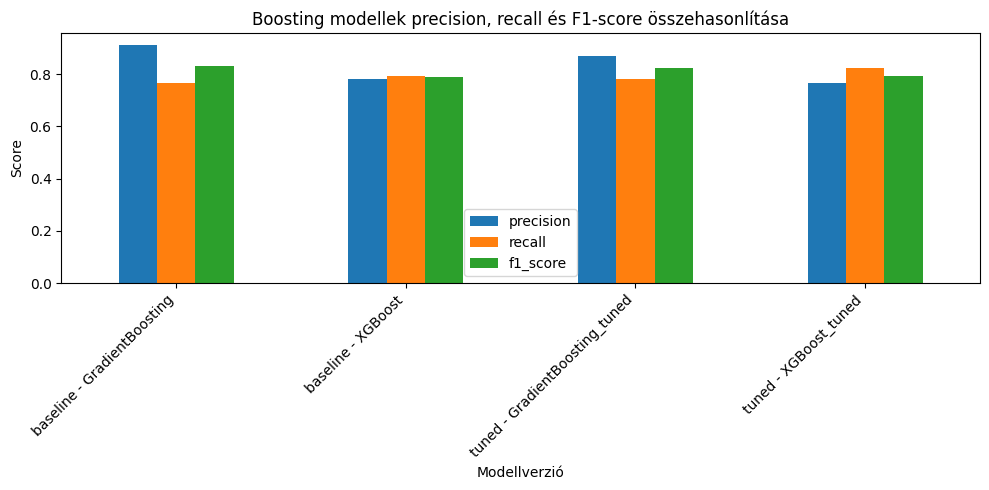

In [47]:
plot_df = comparison_results_df.copy()
plot_df["label"] = plot_df["version"] + " - " + plot_df["model"]

plot_metrics = ["precision", "recall", "f1_score"]

plot_df.set_index("label")[plot_metrics].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Boosting modellek precision, recall és F1-score összehasonlítása")
plt.xlabel("Modellverzió")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 21. Küszöbérték finomhangolása

A klasszifikációs modellek alapértelmezetten 0,5-ös küszöbértékkel döntenek:

- ha `P(target=1) >= 0.5`, akkor a predikció `1`,
- különben a predikció `0`.

Kiegyensúlyozatlan adathalmaz esetén ez a threshold túl szigorú lehet, ezért megvizsgáljuk, hogy más küszöbérték mellett javítható-e a precision, recall vagy F1-score.

A threshold kiválasztását a train adaton belüli keresztvalidációs predikciók alapján végezzük, nem a test adaton.

In [48]:
best_tuned_model_name = random_search_results_df.sort_values(
    by="best_f1_cv",
    ascending=False
).iloc[0]["model"]

best_tuned_model = best_tuned_models[best_tuned_model_name]

print(f"A CV F1-score alapján legjobb tuningolt modell: {best_tuned_model_name}")

A CV F1-score alapján legjobb tuningolt modell: GradientBoosting_tuned


In [49]:
oof_proba = cross_val_predict(
    best_tuned_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

oof_proba[:10]

array([0.00201608, 0.00125881, 0.0038936 , 0.00327288, 0.00067177,
       0.00094348, 0.003064  , 0.00149618, 0.0010178 , 0.00143064])

In [50]:
threshold_values = np.arange(0.05, 0.96, 0.01)

threshold_results = []

for threshold in threshold_values:
    y_pred_threshold = (oof_proba >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_train, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_train, y_pred_threshold, zero_division=0),
        "f1_score": f1_score(y_train, y_pred_threshold, zero_division=0)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.sort_values("f1_score", ascending=False).head(10)

,threshold,precision,recall,f1_score
35,0.40,0.876106,0.730627,0.796781
39,0.44,0.890411,0.719557,0.795918
37,0.42,0.882883,0.723247,0.795132
38,0.43,0.886364,0.719557,0.794297
34,0.39,0.864629,0.730627,0.792000
36,0.41,0.875000,0.723247,0.791919
40,0.45,0.889401,0.712177,0.790984
33,0.38,0.860870,0.730627,0.790419
31,0.36,0.847458,0.738007,0.788955
28,0.33,0.837500,0.741697,0.786693


In [51]:
best_threshold_row = threshold_results_df.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["threshold"]

print("Legjobb threshold F1-score alapján:")
print(best_threshold_row)

Legjobb threshold F1-score alapján:
threshold    0.400000
precision    0.876106
recall       0.730627
f1_score     0.796781
Name: 35, dtype: float64


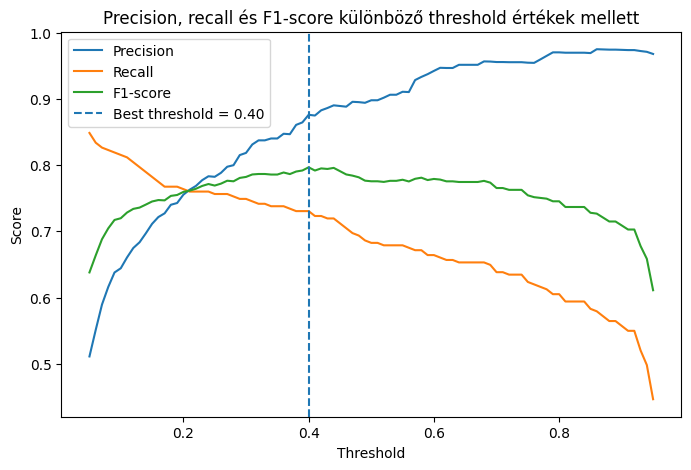

In [52]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1_score"],
    label="F1-score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.title("Precision, recall és F1-score különböző threshold értékek mellett")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## 22. Végső tesztelés optimalizált threshold mellett

A train adaton keresztvalidációval kiválasztott thresholdot ezután a test adaton alkalmazzuk.

A threshold módosítása nem változtatja meg a modell által becsült valószínűségek sorrendjét, ezért a ROC-AUC és average precision érték változatlan marad. A threshold tuning elsősorban a végső 0/1 osztálydöntést módosítja, így a precision, recall és F1-score értékekre van hatással.

In [53]:
best_tuned_model.fit(X_train, y_train)

test_proba_best_tuned = best_tuned_model.predict_proba(X_test)[:, 1]

test_pred_default_threshold = (test_proba_best_tuned >= 0.5).astype(int)
test_pred_optimized_threshold = (test_proba_best_tuned >= best_threshold).astype(int)

In [54]:
threshold_comparison_df = pd.DataFrame([
    {
        "model": best_tuned_model_name,
        "threshold_type": "default_0.5",
        "threshold": 0.5,
        "accuracy": accuracy_score(y_test, test_pred_default_threshold),
        "precision": precision_score(y_test, test_pred_default_threshold, zero_division=0),
        "recall": recall_score(y_test, test_pred_default_threshold, zero_division=0),
        "f1_score": f1_score(y_test, test_pred_default_threshold, zero_division=0),
        "roc_auc": roc_auc_score(y_test, test_proba_best_tuned),
        "average_precision": average_precision_score(y_test, test_proba_best_tuned)
    },
    {
        "model": best_tuned_model_name,
        "threshold_type": "optimized",
        "threshold": best_threshold,
        "accuracy": accuracy_score(y_test, test_pred_optimized_threshold),
        "precision": precision_score(y_test, test_pred_optimized_threshold, zero_division=0),
        "recall": recall_score(y_test, test_pred_optimized_threshold, zero_division=0),
        "f1_score": f1_score(y_test, test_pred_optimized_threshold, zero_division=0),
        "roc_auc": roc_auc_score(y_test, test_proba_best_tuned),
        "average_precision": average_precision_score(y_test, test_proba_best_tuned)
    }
])

threshold_comparison_df.round(4)

,model,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,GradientBoosting_tuned,default_0.5,0.5,0.9885,0.8689,0.7794,0.8217,0.9707,0.8366
1,GradientBoosting_tuned,optimized,0.4,0.9885,0.8571,0.7941,0.8244,0.9707,0.8366


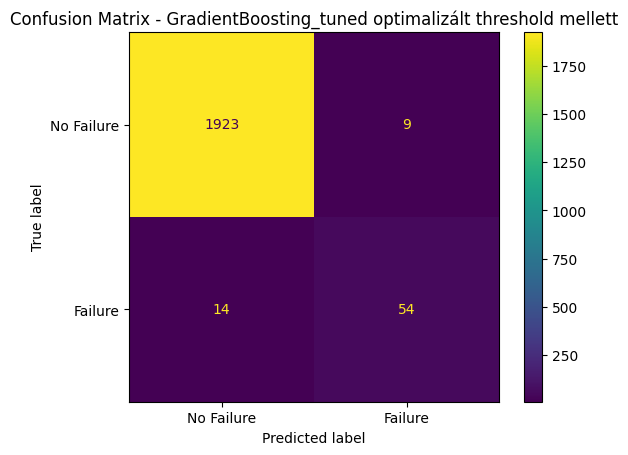

In [55]:
cm_optimized = confusion_matrix(
    y_test,
    test_pred_optimized_threshold
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_optimized,
    display_labels=["No Failure", "Failure"]
)

disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {best_tuned_model_name} optimalizált threshold mellett")
plt.show()

## 23. Végső eredménytábla összeállítása

Az eredményeket egy közös táblába rendezzük:

- baseline modellek,
- tuningolt modellek,
- threshold tuninggal javított végső modell.

Ezt a táblát CSV fájlba is mentjük, hogy később a teljes modell-összehasonlítás során felhasználható legyen.

In [56]:
optimized_threshold_result_df = threshold_comparison_df[
    threshold_comparison_df["threshold_type"] == "optimized"
].copy()

all_boosting_results_df = pd.concat(
    [
        comparison_results_df,
        optimized_threshold_result_df.assign(version="threshold_tuned")
    ],
    ignore_index=True
)

all_boosting_results_df.round(4)

,version,model,accuracy,precision,recall,f1_score,roc_auc,average_precision,threshold_type,threshold
0,baseline,GradientBoosting,0.9895,0.912281,0.764706,0.832,0.976111,0.866532,NaN,NaN
1,baseline,XGBoost,0.9855,0.782609,0.794118,0.788321,0.981062,0.86101,NaN,NaN
2,tuned,GradientBoosting_tuned,0.9885,0.868852,0.779412,0.821705,0.970718,0.836641,NaN,NaN
3,tuned,XGBoost_tuned,0.9855,0.767123,0.823529,0.794326,0.976822,0.868251,NaN,NaN
4,threshold_tuned,GradientBoosting_tuned,0.9885,0.857143,0.794118,0.824427,0.970718,0.836641,optimized,0.4


A threshold tuning eredménye alapján a 0,40-es küszöb kis mértékben növelte a recall értéket a tuningolt GradientBoosting modellnél. A recall 0,7794-ről 0,7941-re nőtt, miközben a precision 0,8689-ről 0,8571-re csökkent. Ez a várt trade-off: alacsonyabb threshold mellett a modell több esetet sorol pozitívnak, így több valódi hibát talál meg, de több hamis pozitív jelzést is adhat.

Az F1-score 0,8217-ről 0,8244-re javult, tehát a threshold tuning kis mértékű javulást eredményezett a tuningolt GradientBoosting modellhez képest. Ugyanakkor ez az érték továbbra is elmarad a baseline GradientBoosting 0,8320 F1-score értékétől.

In [57]:
BOOSTING_RESULTS_PATH = Path("boosting_results_tuned.csv")

all_boosting_results_df.to_csv(BOOSTING_RESULTS_PATH, index=False)

print(f"Boosting eredmények mentve ide: {BOOSTING_RESULTS_PATH.resolve()}")

Boosting eredmények mentve ide: /home/matetopolyai/mateown/repo/MLBeadando/Codes/Models/Boosting/boosting_results_tuned.csv


## 24. Rövid eredményértelmezés

A Gradient Boosting és XGBoost modellek célja az volt, hogy fa alapú ensemble módszerekkel javítsuk a meghibásodási esetek felismerését. Ezek a modellek képesek nemlineáris kapcsolatok és változók közötti interakciók kezelésére, ezért jól illeszkedhetnek predictive maintenance jellegű tabuláris adatokhoz.

A baseline modellek közül a GradientBoostingClassifier teljesített a legjobban F1-score alapján. A test adathalmazon 0,9895 accuracy, 0,9123 precision, 0,7647 recall és 0,8320 F1-score értéket ért el. Ez azt jelenti, hogy a modell jó egyensúlyt adott a meghibásodások felismerése és a hamis riasztások alacsonyan tartása között.

Az XGBoost baseline modell valamivel magasabb recall értéket ért el, mint a GradientBoosting baseline modell, azonban precision és F1-score alapján gyengébben teljesített. Ez azt jelzi, hogy az XGBoost több hibás esetet talált meg, de több hamis pozitív jelzést is adott.

A hiperparaméter-tuning után a tuned XGBoost recall értéke 0,8235-re nőtt, ami a legmagasabb recall érték a vizsgált boosting modellek között. Ez predictive maintenance szempontból előnyös lehet, ha a fő cél a meghibásodások minél nagyobb arányú felismerése. Ugyanakkor az F1-score alapján továbbra is a baseline GradientBoosting modell maradt a legerősebb.

A threshold tuning során a legjobb keresztvalidációs F1-score alapján kiválasztott modellhez 0,40-es döntési küszöb bizonyult optimálisnak. Ez kis mértékben növelte a recall értéket, de az F1-score továbbra sem haladta meg a baseline GradientBoosting eredményét.

Összességében a végső boosting eredmények alapján F1-score szerint a baseline GradientBoostingClassifier tekinthető a legjobb modellnek. Ha azonban a cél kifejezetten a meghibásodások minél nagyobb arányú felismerése, akkor a tuned XGBoost modell is releváns alternatíva lehet a magasabb recall miatt.

In [58]:
best_final_result = all_boosting_results_df.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

print("Legjobb végső boosting eredmény F1-score alapján:")
print(best_final_result)

Legjobb végső boosting eredmény F1-score alapján:
version                      baseline
model                GradientBoosting
accuracy                       0.9895
precision                    0.912281
recall                       0.764706
f1_score                        0.832
roc_auc                      0.976111
average_precision            0.866532
threshold_type                    NaN
threshold                         NaN
Name: 0, dtype: object


In [59]:
best_final_result_df = all_boosting_results_df.sort_values(
    by="f1_score",
    ascending=False
).head(1)

best_final_result_df.round(4)

,version,model,accuracy,precision,recall,f1_score,roc_auc,average_precision,threshold_type,threshold
0,baseline,GradientBoosting,0.9895,0.912281,0.764706,0.832,0.976111,0.866532,NaN,NaN
